# 🤖 Notebook 3: Traditional Machine Learning Pipeline

**Môn học:** Học Máy (CO3001) — Học kỳ I, Năm học 2025–2026  
**Trường:** Đại học Bách Khoa, ĐHQG-HCM  
**Giảng viên hướng dẫn:** TS. Lê Thành Sách  
**Nhóm:** 13

---

### 🎯 Mục tiêu Notebook này
- Train & đánh giá các mô hình ML truyền thống trên **Adult Census Income** dataset
- So sánh hiệu suất giữa các model: LR, SVM, KNN, Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM
- Feature importance, learning curve, ROC curve, confusion matrix
- **Hyperparameter tuning** với GridSearchCV (Random Forest)
- Lưu best model và kết quả để `04_Deep_Learning` sử dụng

---
**📋 Thứ tự chạy:** `01_EDA` → `02_Preprocessing` → **`03_Traditional_ML`** → `04_Deep_Learning`  
> ⚠️ Cần chạy `02_Preprocessing` trước để tạo các file `.npy` trong `features/` và `models/preprocessor.pkl`.

## 1. 📦 Import Thư Viện & Cấu Hình Đường Dẫn

In [43]:
import subprocess, sys
for pkg in ['category_encoders', 'lightgbm', 'xgboost']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=False)
print('✅ Cài đặt hoàn tất!')

✅ Cài đặt hoàn tất!


In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, urllib.request, joblib, time

from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, learning_curve, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (12, 6), 'figure.dpi': 100})

# ── Cấu hình đường dẫn (giống main_notebook) ──────────────────────────────
_NB_DIR  = os.path.dirname(os.path.abspath('__file__'))  # notebooks/
ROOT_DIR = os.path.abspath(os.path.join(_NB_DIR, '..'))  # project root

DATA_DIR      = os.path.join(ROOT_DIR, 'data')
RAW_DATA_DIR  = os.path.join(DATA_DIR, 'raw')
PROC_DATA_DIR = os.path.join(DATA_DIR, 'processed')
FEAT_DIR      = os.path.join(ROOT_DIR, 'features')
MOD_DIR       = os.path.join(ROOT_DIR, 'models')
REP_DIR       = os.path.join(ROOT_DIR, 'reports')
FIG_DIR       = os.path.join(REP_DIR,  'figures')

for d in [DATA_DIR, RAW_DATA_DIR, PROC_DATA_DIR, FEAT_DIR, MOD_DIR, REP_DIR, FIG_DIR]:
    os.makedirs(d, exist_ok=True)

RANDOM_STATE = 42

print(f'📁 Project root    : {ROOT_DIR}')
print(f'   features/       : {FEAT_DIR}')
print(f'   models/         : {MOD_DIR}')
print(f'   reports/        : {REP_DIR}')
print(f'✅ Import thư viện hoàn tất!')

📁 Project root    : d:\252\3. Machine Learning\ML_Project_Tabular
   features/       : d:\252\3. Machine Learning\ML_Project_Tabular\features
   models/         : d:\252\3. Machine Learning\ML_Project_Tabular\models
   reports/        : d:\252\3. Machine Learning\ML_Project_Tabular\reports
✅ Import thư viện hoàn tất!


## 2. 📥 Load Features
Ưu tiên load từ file `.npy` đã được lưu bởi `02_Preprocessing`.  
Nếu chưa có → tự tải dữ liệu và preprocessing lại.

In [45]:
FEAT_TRAIN = os.path.join(FEAT_DIR, 'X_train_preprocessed.npy')
FEAT_TEST  = os.path.join(FEAT_DIR, 'X_test_preprocessed.npy')
Y_TRAIN    = os.path.join(FEAT_DIR, 'y_train.npy')
Y_TEST     = os.path.join(FEAT_DIR, 'y_test.npy')
FEAT_NAMES = os.path.join(FEAT_DIR, 'feature_names.txt')
PCA_PATH   = os.path.join(MOD_DIR, 'pca_95.pkl')
PREP_PATH  = os.path.join(MOD_DIR, 'preprocessor.pkl')

if all(os.path.exists(p) for p in [FEAT_TRAIN, FEAT_TEST, Y_TRAIN, Y_TEST]):
    # ── Load từ file ───────────────────────────────────────────────────────
    X_train_proc = np.load(FEAT_TRAIN)
    X_test_proc  = np.load(FEAT_TEST)
    y_train      = pd.Series(np.load(Y_TRAIN))
    y_test       = pd.Series(np.load(Y_TEST))
    preprocessor = joblib.load(PREP_PATH) if os.path.exists(PREP_PATH) else None
    print(f'✅ Loaded từ file: train={X_train_proc.shape}, test={X_test_proc.shape}')

    if os.path.exists(PCA_PATH):
        pca_path_train = os.path.join(FEAT_DIR, 'X_train_pca.npy')
        pca_path_test  = os.path.join(FEAT_DIR, 'X_test_pca.npy')
        if os.path.exists(pca_path_train):
            X_train_pca = np.load(pca_path_train)
            X_test_pca  = np.load(pca_path_test)
            print(f'✅ PCA features: train={X_train_pca.shape}')
        else:
            pca_95 = joblib.load(PCA_PATH)
            X_train_pca = pca_95.transform(X_train_proc)
            X_test_pca  = pca_95.transform(X_test_proc)
    else:
        pca_95 = PCA(n_components=0.95, random_state=RANDOM_STATE)
        X_train_pca = pca_95.fit_transform(X_train_proc)
        X_test_pca  = pca_95.transform(X_test_proc)

    if os.path.exists(FEAT_NAMES):
        with open(FEAT_NAMES, encoding='utf-8') as f:
            feat_names = [l.strip() for l in f.readlines()]
    else:
        feat_names = [f'f{i}' for i in range(X_train_proc.shape[1])]

else:
    # ── Fallback: tự preprocessing ─────────────────────────────────────────
    print('⚠️  Không tìm thấy features/ → tự preprocessing...')

    COLUMNS    = ['age','workclass','fnlwgt','education','education_num',
                  'marital_status','occupation','relationship','race','sex',
                  'capital_gain','capital_loss','hours_per_week','native_country','income']
    TRAIN_URL  = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
    TEST_URL   = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test'
    TRAIN_PATH = os.path.join(RAW_DATA_DIR, 'adult_train.csv')
    TEST_PATH  = os.path.join(RAW_DATA_DIR, 'adult_test.csv')

    if not os.path.exists(TRAIN_PATH):
        urllib.request.urlretrieve(TRAIN_URL, TRAIN_PATH)
        urllib.request.urlretrieve(TEST_URL,  TEST_PATH)

    df_train = pd.read_csv(TRAIN_PATH, names=COLUMNS, sep=r',\s*', engine='python', na_values='?')
    df_test  = pd.read_csv(TEST_PATH,  names=COLUMNS, sep=r',\s*', engine='python', na_values='?', skiprows=1)
    df_full  = pd.concat([df_train, df_test], ignore_index=True)
    df_full['income'] = df_full['income'].str.replace('.', '', regex=False).str.strip()
    df = df_full.drop_duplicates().reset_index(drop=True)

    numeric_features     = ['age','fnlwgt','education_num','capital_gain','capital_loss','hours_per_week']
    categorical_features = ['workclass','education','marital_status','occupation',
                            'relationship','race','sex','native_country']

    X = df.drop(columns=['income'])
    y = (df['income'] == '>50K').astype(int)
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

    preprocessor = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                          ('sc',  StandardScaler())]), numeric_features),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                          ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
                          categorical_features),
    ])
    X_train_proc = preprocessor.fit_transform(X_train_raw, y_train)
    X_test_proc  = preprocessor.transform(X_test_raw)

    pca_95 = PCA(n_components=0.95, random_state=RANDOM_STATE)
    X_train_pca = pca_95.fit_transform(X_train_proc)
    X_test_pca  = pca_95.transform(X_test_proc)

    try:
        ohe_names  = preprocessor.named_transformers_['cat']['enc'].get_feature_names_out(categorical_features)
        feat_names = list(numeric_features) + list(ohe_names)
    except Exception:
        feat_names = [f'f{i}' for i in range(X_train_proc.shape[1])]

    print(f'✅ Self-preprocessing: train={X_train_proc.shape}, test={X_test_proc.shape}')

print(f'\nTrain: {X_train_proc.shape}  |  Test: {X_test_proc.shape}')
print(f'PCA  : {X_train_pca.shape}   |  Features: {len(feat_names)}')

✅ Loaded từ file: train=(39032, 105), test=(9758, 105)
✅ PCA features: train=(39032, 31)

Train: (39032, 105)  |  Test: (9758, 105)
PCA  : (39032, 31)   |  Features: 105


## 3. 🧠 Định Nghĩa Các Mô Hình

In [46]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'
    ),
    'SVM (RBF)': SVC(
        kernel='rbf', probability=True,
        random_state=RANDOM_STATE, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=RANDOM_STATE,
        n_jobs=-1, class_weight='balanced'
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100, random_state=RANDOM_STATE,
        use_label_encoder=False, eval_metric='logloss',
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()  # xử lý imbalance
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=100, random_state=RANDOM_STATE,
        verbose=-1, class_weight='balanced'
    ),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(
        random_state=RANDOM_STATE, class_weight='balanced', max_depth=10
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, random_state=RANDOM_STATE
    ),
}
print(f'✅ Đã định nghĩa {len(models)} mô hình:')
for name in models:
    print(f'   • {name}')

✅ Đã định nghĩa 8 mô hình:
   • Logistic Regression
   • SVM (RBF)
   • Random Forest
   • XGBoost
   • LightGBM
   • KNN
   • Decision Tree
   • Gradient Boosting


## 4. 🏋️ Huấn Luyện & Đánh Giá — Raw Features

In [47]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name=''):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None
    return {
        'accuracy'   : accuracy_score(y_te, y_pred),
        'precision'  : precision_score(y_te, y_pred, zero_division=0),
        'recall'     : recall_score(y_te, y_pred, zero_division=0),
        'f1'         : f1_score(y_te, y_pred, zero_division=0),
        'roc_auc'    : roc_auc_score(y_te, y_proba) if y_proba is not None else np.nan,
        'train_time' : round(train_time, 2),
    }

print('Huấn luyện trên Raw features...')
print('-' * 70)
results_raw = {}
trained_models = {}

for name, model in models.items():
    res = evaluate_model(model, X_train_proc, y_train, X_test_proc, y_test, name)
    results_raw[name] = res
    trained_models[name] = model
    print(f'[{name:<22}] acc={res["accuracy"]:.4f}  f1={res["f1"]:.4f}  '
          f'auc={res["roc_auc"]:.4f}  t={res["train_time"]}s')

results_raw_df = pd.DataFrame(results_raw).T
results_raw_df = results_raw_df.sort_values('f1', ascending=False)

print('\n=== Top 5 (by F1) ===')
print(results_raw_df[['accuracy','precision','recall','f1','roc_auc','train_time']].head(5).round(4).to_string())

Huấn luyện trên Raw features...
----------------------------------------------------------------------
[Logistic Regression   ] acc=0.8082  f1=0.6801  auc=0.9080  t=0.28s
[SVM (RBF)             ] acc=0.8073  f1=0.6824  auc=0.9048  t=494.83s
[Random Forest         ] acc=0.8565  f1=0.6764  auc=0.9053  t=0.64s
[XGBoost               ] acc=0.8395  f1=0.7198  auc=0.9319  t=0.23s
[LightGBM              ] acc=0.8343  f1=0.7150  auc=0.9330  t=0.15s
[KNN                   ] acc=0.8389  f1=0.6442  auc=0.8667  t=0.0s
[Decision Tree         ] acc=0.7988  f1=0.6756  auc=0.9004  t=0.34s
[Gradient Boosting     ] acc=0.8704  f1=0.6972  auc=0.9248  t=9.97s

=== Top 5 (by F1) ===
                     accuracy  precision  recall      f1  roc_auc  train_time
XGBoost                0.8395     0.6184  0.8609  0.7198   0.9319        0.23
LightGBM               0.8343     0.6077  0.8682  0.7150   0.9330        0.15
Gradient Boosting      0.8704     0.7909  0.6233  0.6972   0.9248        9.97
SVM (RBF)        

## 5. 📉 Huấn Luyện — PCA Features (So Sánh)

In [48]:
print('Huấn luyện trên PCA features...')
print('-' * 70)
results_pca = {}

# Chỉ chạy fast models cho PCA comparison
fast_models = {k: v for k, v in models.items()
               if k not in ['SVM (RBF)', 'KNN']}  # bỏ slow models

for name, model in fast_models.items():
    import copy
    m = copy.deepcopy(model)
    res = evaluate_model(m, X_train_pca, y_train, X_test_pca, y_test, name)
    results_pca[name] = res
    print(f'[{name:<22}] acc={res["accuracy"]:.4f}  f1={res["f1"]:.4f}  auc={res["roc_auc"]:.4f}')

results_pca_df = pd.DataFrame(results_pca).T.sort_values('f1', ascending=False)

Huấn luyện trên PCA features...
----------------------------------------------------------------------
[Logistic Regression   ] acc=0.8047  f1=0.6773  auc=0.9060
[Random Forest         ] acc=0.8410  f1=0.6338  auc=0.8952
[XGBoost               ] acc=0.8208  f1=0.6822  auc=0.9065
[LightGBM              ] acc=0.8139  f1=0.6864  auc=0.9128
[Decision Tree         ] acc=0.7910  f1=0.6553  auc=0.8522
[Gradient Boosting     ] acc=0.8562  f1=0.6727  auc=0.9103


## 6. 📊 Visualizations & Evaluation

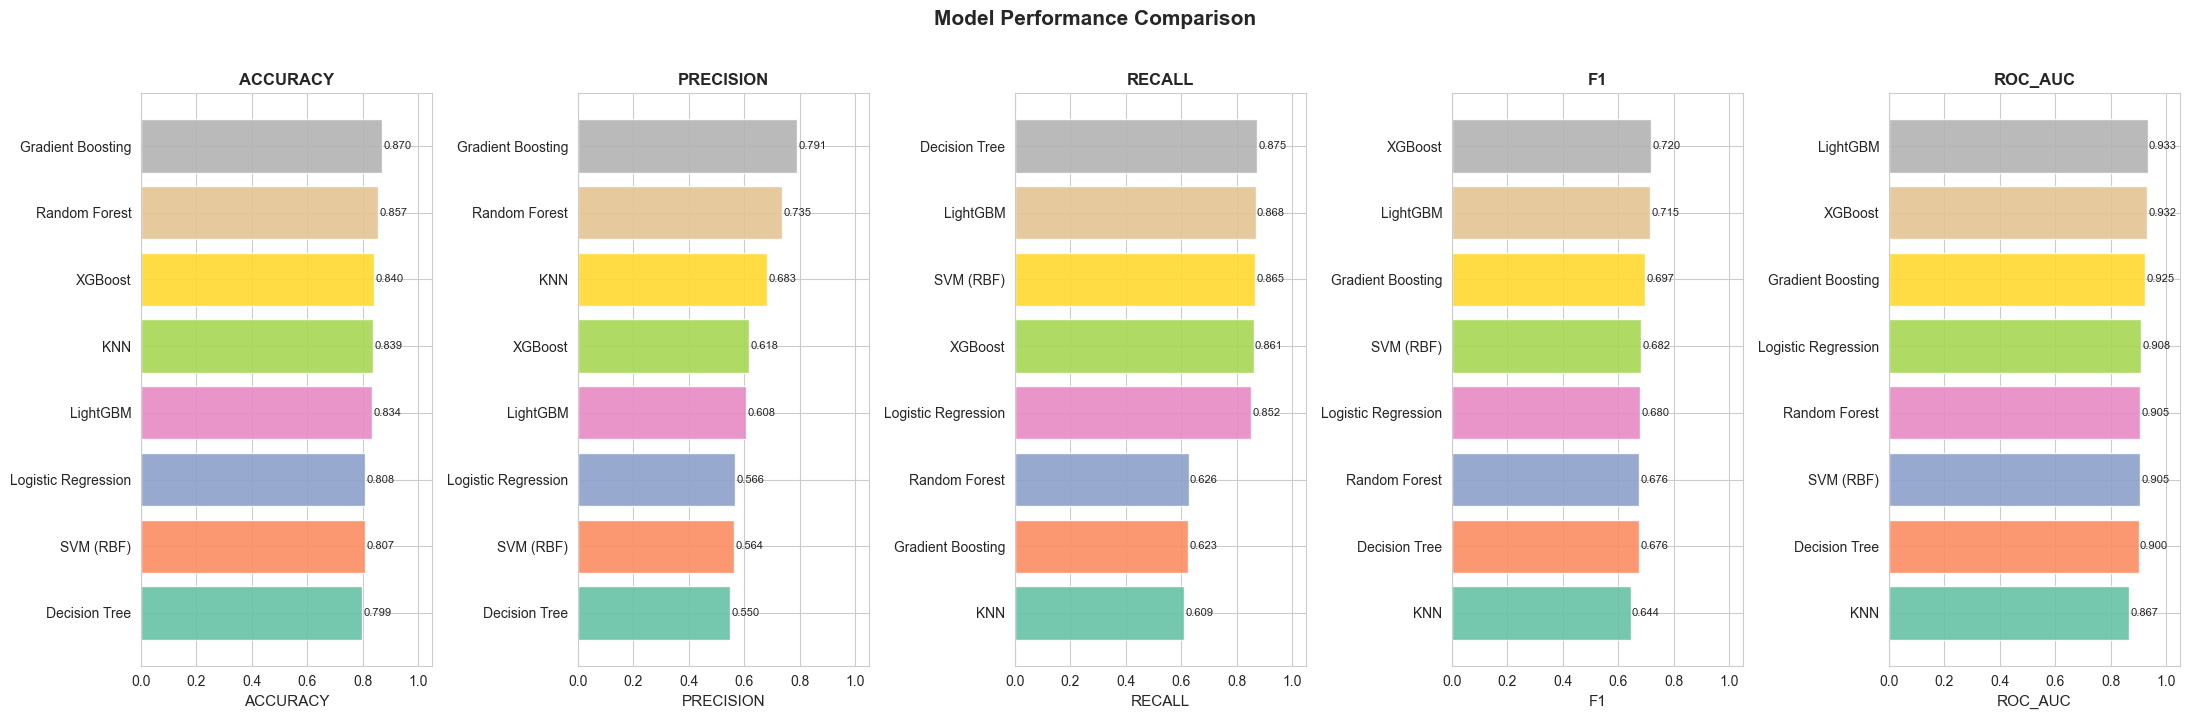

=== Results (Raw Features, sorted by F1) ===
                     accuracy  precision  recall      f1  roc_auc  train_time
XGBoost                0.8395     0.6184  0.8609  0.7198   0.9319        0.23
LightGBM               0.8343     0.6077  0.8682  0.7150   0.9330        0.15
Gradient Boosting      0.8704     0.7909  0.6233  0.6972   0.9248        9.97
SVM (RBF)              0.8073     0.5636  0.8647  0.6824   0.9048      494.83
Logistic Regression    0.8082     0.5660  0.8519  0.6801   0.9080        0.28
Random Forest          0.8565     0.7352  0.6263  0.6764   0.9053        0.64
Decision Tree          0.7988     0.5502  0.8750  0.6756   0.9004        0.34
KNN                    0.8389     0.6835  0.6092  0.6442   0.8667        0.00


In [57]:
# Model comparison chart
results_df = results_raw_df.copy()
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(22, 7))
colors = plt.cm.Set2(np.linspace(0, 1, len(results_df)))

for ax, metric in zip(axes, metrics_to_plot):
    sorted_df = results_df[metric].sort_values()
    bars = ax.barh(sorted_df.index, sorted_df.values,
                   color=colors, edgecolor='white', alpha=0.9)
    ax.set_xlabel(metric.upper(), fontsize=11)
    ax.set_title(metric.upper(), fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1.05)
    for bar, val in zip(bars, sorted_df.values):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print('=== Results (Raw Features, sorted by F1) ===')
print(results_df[['accuracy','precision','recall','f1','roc_auc','train_time']].round(4).to_string())

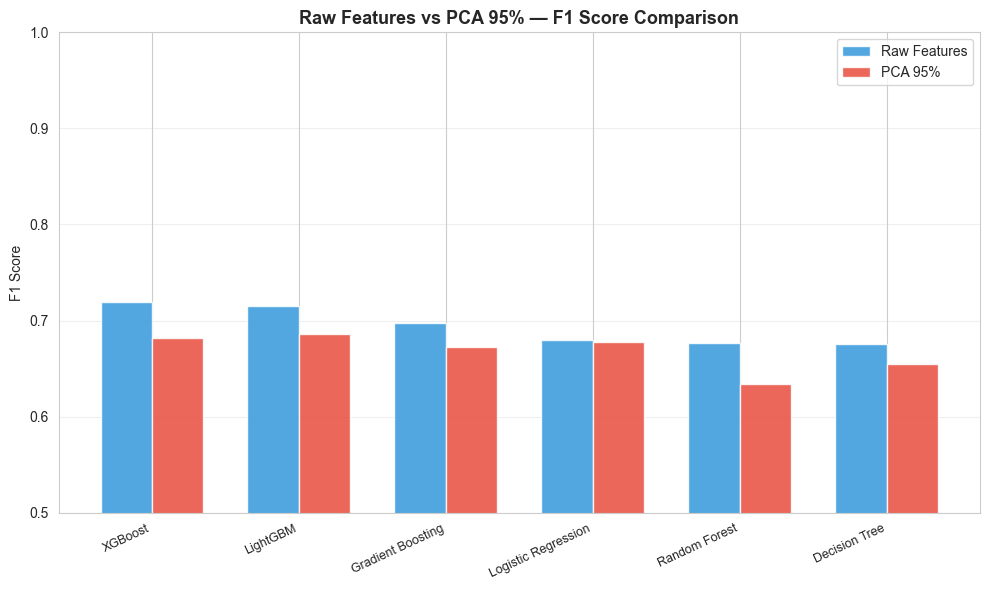

In [50]:
# Raw vs PCA comparison
common = [m for m in results_raw_df.index if m in results_pca_df.index]
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(common))
w = 0.35
ax.bar(x - w/2, [results_raw_df.loc[m,'f1'] for m in common],
       w, label='Raw Features', color='#3498db', alpha=0.85, edgecolor='white')
ax.bar(x + w/2, [results_pca_df.loc[m,'f1'] for m in common],
       w, label='PCA 95%',      color='#e74c3c', alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(common, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('F1 Score')
ax.set_title('Raw Features vs PCA 95% — F1 Score Comparison', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0.5, 1.0)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'raw_vs_pca.png'), dpi=150, bbox_inches='tight')
plt.show()

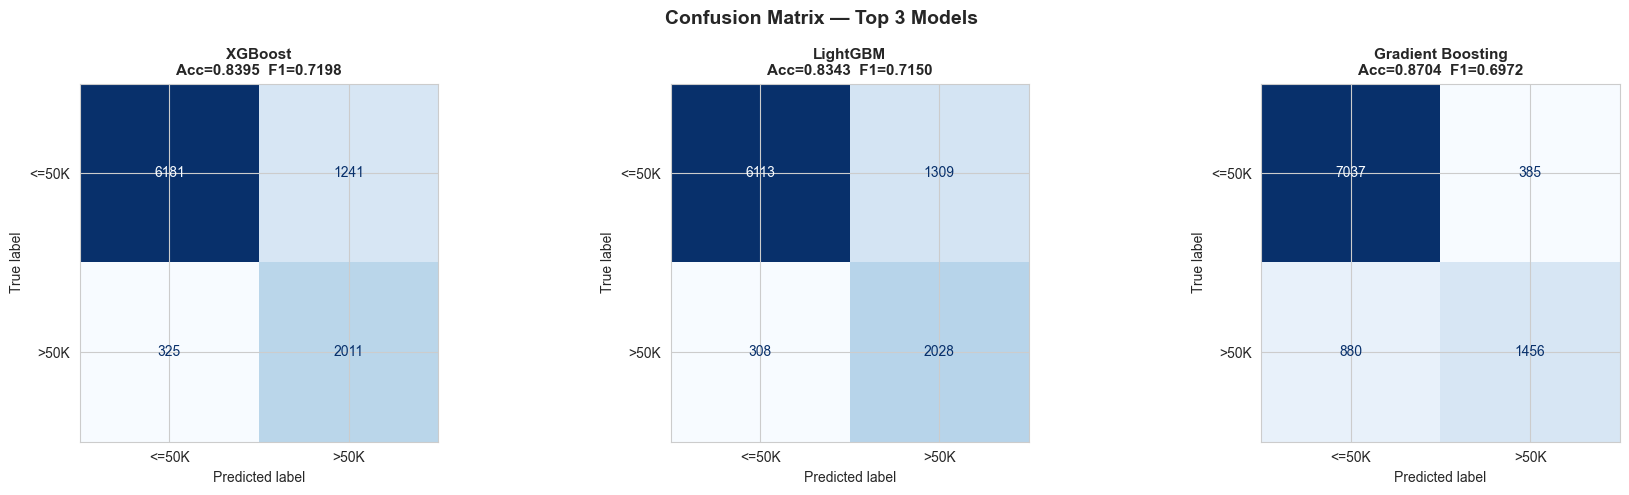

In [51]:
# Confusion Matrix — Top 3 models
top3 = results_df.head(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, name in zip(axes, top3):
    y_pred = trained_models[name].predict(X_test_proc)
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['<=50K', '>50K'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAcc={results_df.loc[name,"accuracy"]:.4f}  F1={results_df.loc[name,"f1"]:.4f}',
                 fontsize=11, fontweight='bold')
plt.suptitle('Confusion Matrix — Top 3 Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

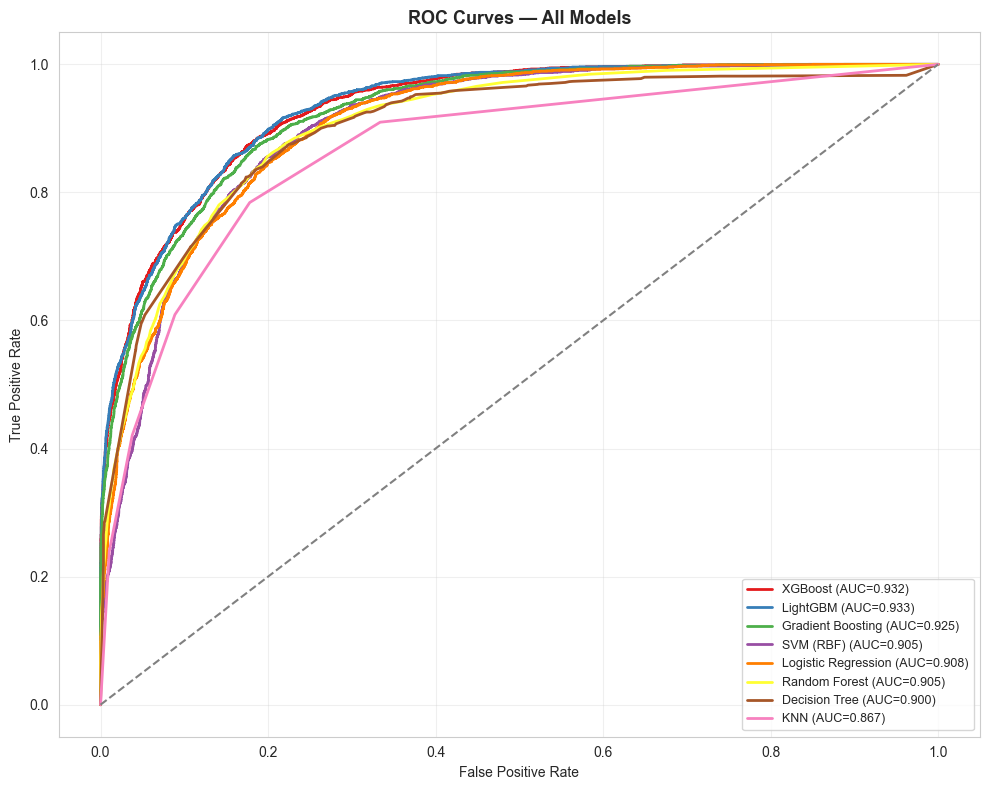

In [52]:
# ROC Curve — tất cả các model
fig, ax = plt.subplots(figsize=(10, 8))
palette = plt.cm.Set1(np.linspace(0, 0.85, len(results_df)))
for (name, _), color in zip(results_df.iterrows(), palette):
    model = trained_models[name]
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_proc)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        ax.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC={auc(fpr,tpr):.3f})')
ax.plot([0, 1], [0, 1], '--', color='grey')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

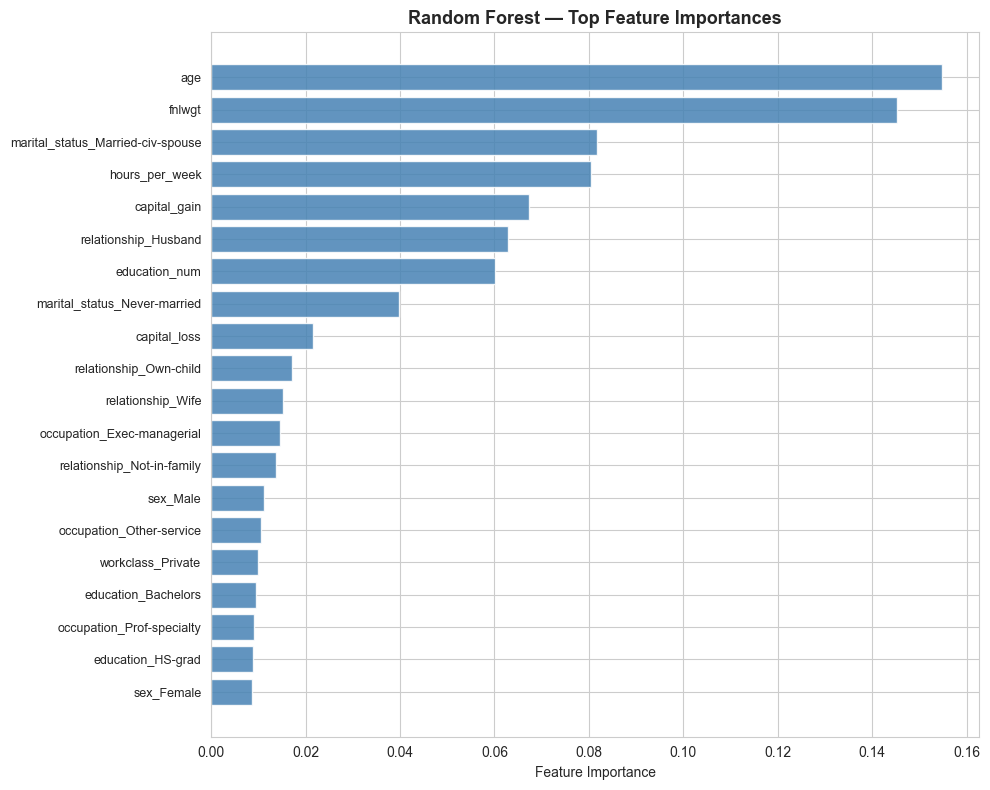

In [53]:
# Feature Importance — Random Forest
best_name  = results_df.index[0]
best_model = trained_models[best_name]

rf_model = trained_models.get('Random Forest')
if rf_model and hasattr(rf_model, 'feature_importances_'):
    importances = rf_model.feature_importances_
    top_n   = min(20, len(feat_names))
    indices = np.argsort(importances)[::-1][:top_n]
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(range(top_n), importances[indices], color='steelblue', alpha=0.85)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([feat_names[i] for i in indices], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Feature Importance')
    ax.set_title('Random Forest — Top Feature Importances', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'feature_importance_rf.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('⚠️  Random Forest model không có feature_importances_')

Learning Curve cho: XGBoost


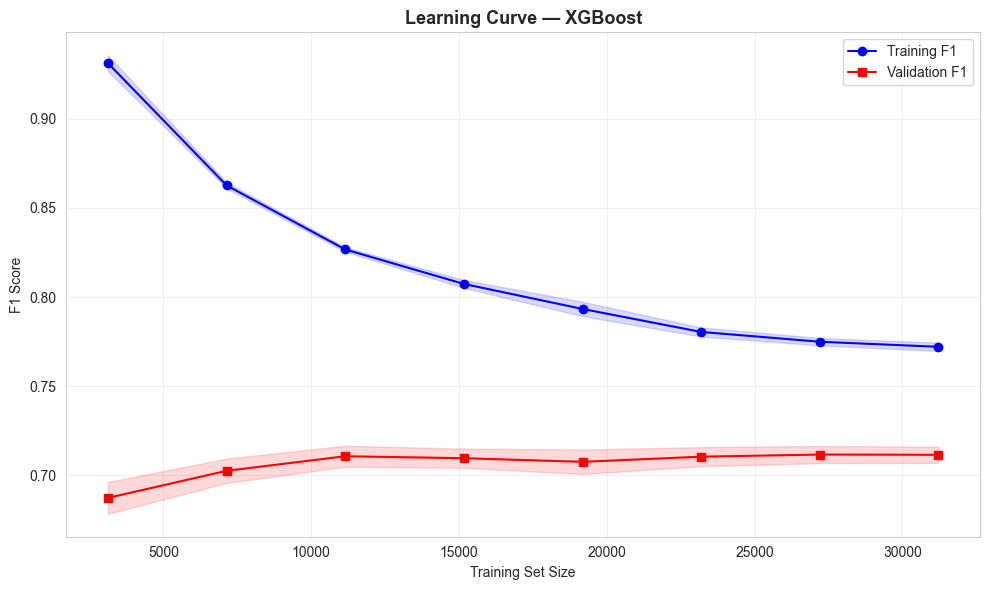

In [54]:
# Learning Curve — Best model
print(f'Learning Curve cho: {best_name}')
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train_proc, y_train, cv=5, n_jobs=-1, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=RANDOM_STATE
)

tr_m, tr_s = train_scores.mean(1), train_scores.std(1)
va_m, va_s = val_scores.mean(1),   val_scores.std(1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, tr_m, 'b-o', label='Training F1')
ax.fill_between(train_sizes, tr_m - tr_s, tr_m + tr_s, alpha=0.15, color='blue')
ax.plot(train_sizes, va_m, 'r-s', label='Validation F1')
ax.fill_between(train_sizes, va_m - va_s, va_m + va_s, alpha=0.15, color='red')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('F1 Score')
ax.set_title(f'Learning Curve — {best_name}', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'learning_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. 🔧 Hyperparameter Tuning — Random Forest

In [55]:
print('GridSearchCV cho Random Forest...')
param_grid = {
    'n_estimators'     : [50, 100, 200],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5],
}
grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced'),
    param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1
)
grid.fit(X_train_proc, y_train)
tuned_rf = grid.best_estimator_
y_pred_tuned = tuned_rf.predict(X_test_proc)

print(f'Best params : {grid.best_params_}')
print(f'Best CV F1  : {grid.best_score_:.4f}')
print(f'Test F1 (orig)  : {results_raw_df.loc["Random Forest","f1"]:.4f}')
print(f'Test F1 (tuned) : {f1_score(y_test, y_pred_tuned):.4f}')

GridSearchCV cho Random Forest...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best params : {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1  : 0.6972
Test F1 (orig)  : 0.6764
Test F1 (tuned) : 0.6951


## 8. 💾 Lưu Kết Quả & Best Model

In [56]:
# Lưu results CSV (để 04_Deep_Learning dùng)
results_df.to_csv(os.path.join(REP_DIR, 'model_results.csv'))

# Lưu best model
joblib.dump(best_model,   os.path.join(MOD_DIR, f'best_model_{best_name.replace(" ","_")}.pkl'))
joblib.dump(tuned_rf,     os.path.join(MOD_DIR, 'best_model_RF_tuned.pkl'))

# Nếu preprocessor chưa được lưu từ notebook 02, lưu lại
if preprocessor is not None:
    joblib.dump(preprocessor, os.path.join(MOD_DIR, 'preprocessor.pkl'))

print(f'✅ Best model   : {best_name}')
print(f'   Accuracy    : {results_df.loc[best_name,"accuracy"]:.4f}')
print(f'   F1          : {results_df.loc[best_name,"f1"]:.4f}')
print(f'   ROC-AUC     : {results_df.loc[best_name,"roc_auc"]:.4f}')
print(f'\n📦 Files đã lưu:')
print(f'   {REP_DIR}/model_results.csv')
print(f'   {MOD_DIR}/best_model_{best_name.replace(" ","_")}.pkl')
print(f'   {MOD_DIR}/best_model_RF_tuned.pkl')
print()
print('✅ Hoàn thành! Chạy 04_Deep_Learning.ipynb (Bonus) tiếp theo.')

✅ Best model   : XGBoost
   Accuracy    : 0.8395
   F1          : 0.7198
   ROC-AUC     : 0.9319

📦 Files đã lưu:
   d:\252\3. Machine Learning\ML_Project_Tabular\reports/model_results.csv
   d:\252\3. Machine Learning\ML_Project_Tabular\models/best_model_XGBoost.pkl
   d:\252\3. Machine Learning\ML_Project_Tabular\models/best_model_RF_tuned.pkl

✅ Hoàn thành! Chạy 04_Deep_Learning.ipynb (Bonus) tiếp theo.
